In [1]:

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

# Carrega os dados do CSV. Delimiter=',' indica que as colunas são separadas por vírgula.
# skiprows=2 para pular as duas linhas de cabeçalho/comentário
dataset = np.loadtxt("tumores.csv", delimiter=',', skiprows=2)

# Separa as colunas de características (features) e a coluna de rótulos (labels)
# X_train recebe todas as linhas, mas apenas as duas primeiras colunas (índice 0 e 1)
X_train = dataset[:, :2]

# y_train recebe todas as linhas, mas apenas a última coluna (índice 2)
# .astype(int) para garantir que as classes sejam tratadas como inteiros
y_train = dataset[:, 2].astype(int)

print("Amostra das características (X_train): ")
print(X_train[:5])
print("\nAmostra dos rótulos (y_train): ")
print(y_train[:5])

# Saída
# Amostra das características (X_train): 
# [[1.9 2.5]
#  [3.  3.9]
#  [3.5 2.9]
#  [2.2 2.2]
#  [4.  4.5]]

# Amostra deos rótulos (y_train): 
# [0 0 0 0 0]

Amostra das características (X_train): 
[[1.9 2.5]
 [3.  3.9]
 [3.5 2.9]
 [2.2 2.2]
 [4.  4.5]]

Amostra dos rótulos (y_train): 
[0 0 0 0 0]


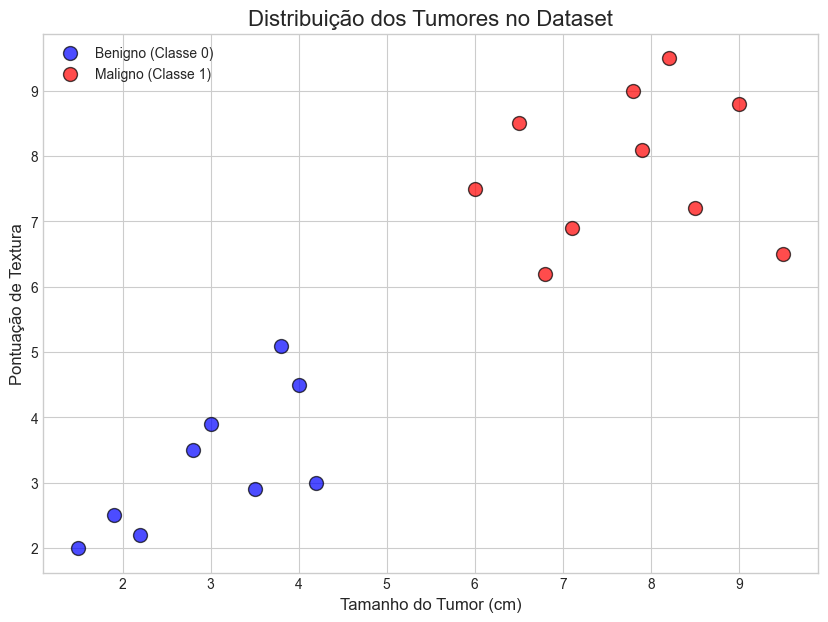

In [2]:

plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 7))

# Plota os pontos Benignos (Classe 0)
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c='blue', s=100, edgecolor='k', alpha=0.7, label='Benigno (Classe 0)')

# Plota os pontos Malignos (Classe 1)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c='red', s=100, edgecolor='k', alpha=0.7, label='Maligno (Classe 1)')

ax.set_title("Distribuição dos Tumores no Dataset", fontsize=16)
ax.set_xlabel("Tamanho do Tumor (cm)", fontsize=12)
ax.set_ylabel("Pontuação de Textura", fontsize=12)
ax.legend()
plt.show()

In [3]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """""Calcula a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1-ponto2)**2))

def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos mais próximos de um ponto de teste."""
    distancias = []
    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))

    # Ordena a lista de distâncias em ordem crescente
    distancias.sort(key=lambda x: x[0])

    # Retorna os k vizinhos mais próximos (seus rótulos)
    vizinhos = [distancia[1] for distancia in distancias[:k]]
    return vizinhos

def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto majoritário dos vizinhos."""
    # Conta a ocorrência de cada classe nos vizinhos
    contagem_votos = Counter(vizinhos)
    # Retorna a classe mais comum
    previsao = contagem_votos.most_common(1)[0][0]
    return previsao

In [4]:
# Ponto que queremos classificar
novo_tumor = np.array([5.5, 6.0])
k = 5

# Encontra os vizinhos e faz a previsão
vizinhos_proximos = encontrar_vizinhos(X_train, y_train, novo_tumor, k)
previsao_final = prever_classificacao(vizinhos_proximos)

# Mapeia o resultado para um texto explicativo
resultado_texto = "Benigno" if previsao_final == 0 else "Maligno"

print(f"O novo turmo tem as características: {novo_tumor}")
print(f"O valor de 'k' escolhido foi: {k}")
print(f"As classes dos vizinhos mais próximos são: {vizinhos_proximos}")
print("-------------------------------------------------------")
print(f"--> Previsão Final: O novo tumor é classificado como {resultado_texto} (Classe {previsao_final})")

# Saída
# Amostra das características (X_train): 
# [[1.9 2.5]
#  [3.  3.9]
#  [3.5 2.9]
#  [2.2 2.2]
#  [4.  4.5]]

# Amostra deos rótulos (y_train): 
# [0 0 0 0 0]

# O novo turmo tem as características: [5.5 6. ]
# O valor de 'k' escolhido foi: 5
# As classes dos vizinhos mais próximos são: [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
# -------------------------------------------------------
# --> Previsão Final: O novo tumor é classificado como Maligno (Classe 1)

O novo turmo tem as características: [5.5 6. ]
O valor de 'k' escolhido foi: 5
As classes dos vizinhos mais próximos são: [np.int64(1), np.int64(1), np.int64(1), np.int64(0), np.int64(0)]
-------------------------------------------------------
--> Previsão Final: O novo tumor é classificado como Maligno (Classe 1)


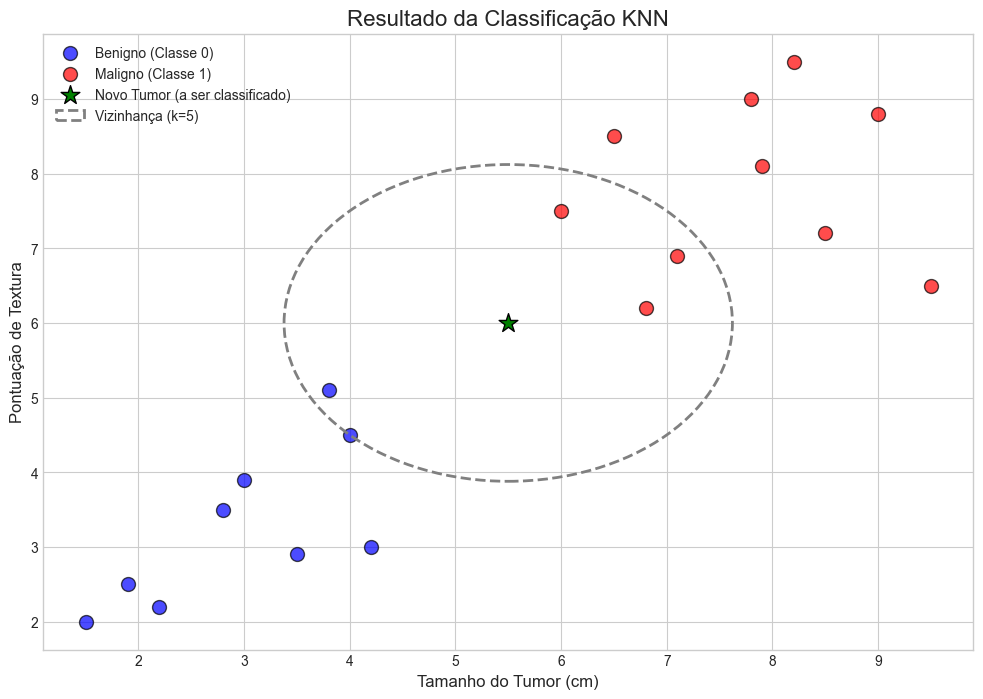

In [5]:

fig, ax = plt.subplots(figsize=(12, 8))

# Plotando os pontos de dados de treinamento
ax.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1],
            c='blue', s=100, edgecolor='k', alpha=0.7, label='Benigno (Classe 0)')
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
            c='red', s=100, edgecolor='k', alpha=0.7, label='Maligno (Classe 1)')

# Plotando o novo ponto de dados a ser classificado
ax.scatter(novo_tumor[0], novo_tumor[1],
            c='green', s=200, edgecolor='k', marker='*', label='Novo Tumor (a ser classificado)')

# Destaque para os vizinhos mais próximos
indices_vizinhos = np.argsort([calcular_distancia_euclidiana(p, novo_tumor) for p in X_train])[:k]
pontos_vizinhos = X_train[indices_vizinhos]

# Desenhando um círculo que engloba os vizinhos
distancia_maxima = calcular_distancia_euclidiana(novo_tumor, pontos_vizinhos[-1])
circulo = plt.Circle(novo_tumor, distancia_maxima, color='gray', fill=False,
                     linestyle='--', linewidth=2, label=f'Vizinhança (k={k})')
ax.add_artist(circulo)

# Configurações do gráfico
ax.set_title("Resultado da Classificação KNN", fontsize=16)
ax.set_xlabel("Tamanho do Tumor (cm)", fontsize=12)
ax.set_ylabel("Pontuação de Textura", fontsize=12)
ax.legend(loc='upper left')
ax.grid(True)
plt.show()